# Imports

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import warnings
warnings.filterwarnings("ignore")

2026-05-07 04:53:16.497888: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 04:53:16.891613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778129597.016453    1309 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778129597.064828    1309 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-07 04:53:17.429471: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Load Data

In [4]:
csv_path = "/mnt/d/Applied_Python_Programming_for_Data_Science/Final_Project/data/jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

# Data Preprocessing

In [ ]:
# Replace invalid wind values
df['wv (m/s)'] = df['wv (m/s)'].replace(-9999.00, 0)
df['max. wv (m/s)'] = df['max. wv (m/s)'].replace(-9999.00, 0)

# Wind feature engineering
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')
wd_rad = df.pop('wd (deg)') * np.pi / 180

df['Wx'] = wv * np.cos(wd_rad)
df['Wy'] = wv * np.sin(wd_rad)

df['max Wx'] = max_wv * np.cos(wd_rad)
df['max Wy'] = max_wv * np.sin(wd_rad)

# Convert to hourly data
df = df[5::6].reset_index(drop=True)

# Datetime
date_time = pd.to_datetime(df.pop('Date Time'),format='%d.%m.%Y %H:%M:%S')

In [6]:
# Time Features

df['hour'] = date_time.dt.hour
df['month'] = date_time.dt.month

# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [7]:
# Feature Engineering

target_col = 'T (degC)'

# Lag feature
df['T_lag1'] = df[target_col].shift(1)

# Rolling features
df['temp_roll_mean_24'] = df[target_col].rolling(24).mean()
df['temp_roll_std_24'] = df[target_col].rolling(24).std()

# Remove NaNs
df = df.dropna().reset_index(drop=True)

feature_cols = df.columns.drop(target_col)

# Train Test Split

In [8]:
# 70:30 split

split_idx = int(len(df) * 0.7)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df[target_col]
y_test = test_df[target_col]

# SARIMA Model

In [9]:
# Scaling for SARIMAX
sarimax_scaler = StandardScaler()

X_train_sarimax = sarimax_scaler.fit_transform(X_train)
X_test_sarimax = sarimax_scaler.transform(X_test)

In [10]:
# SARIMAX Model
sarimax_model = SARIMAX(
    y_train,
    exog=X_train_sarimax,
    order=(5,1,1),
    seasonal_order=(2,0,0,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)

/home/user/aml_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
# Prediction
y_pred_sarimax = sarimax_result.predict(
    start=len(y_train),
    end=len(y_train)+len(y_test)-1,
    exog=X_test_sarimax
)

In [12]:
# Evaluation
rmse_sarimax = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))

mae_sarimax = mean_absolute_error(y_test, y_pred_sarimax)

print(f"SARIMAX RMSE: {rmse_sarimax:.4f}")
print(f"SARIMAX MAE : {mae_sarimax:.4f}")

SARIMAX RMSE: 0.0216
SARIMAX MAE : 0.0173


# XGBoost Model

In [ ]:
# Create Lagged Features
N_LAGS = 24

def create_lagged_features(df, target_col, n_lags):
    df_lagged = df.copy()
    for lag in range(1, n_lags + 1):
        for col in df.columns:
            df_lagged[f'{col}_lag{lag}'] = df[col].shift(lag)
    df_lagged = df_lagged.dropna()
    X = df_lagged.drop(columns=[target_col])
    y = df_lagged[target_col]
    return X, y

# Prepare dataframe
df_xgb = df[feature_cols.tolist() + [target_col]]

X_lagged, y_lagged = create_lagged_features(df_xgb,target_col,N_LAGS)

In [14]:
# Train/Test Split
split_xgb = int(len(X_lagged) * 0.7)

X_train_xgb = X_lagged.iloc[:split_xgb]
X_test_xgb = X_lagged.iloc[split_xgb:]

y_train_xgb = y_lagged.iloc[:split_xgb]
y_test_xgb = y_lagged.iloc[split_xgb:]

In [15]:
# scaling for XGBoost
xgb_scaler = StandardScaler()

X_train_xgb_scaled = xgb_scaler.fit_transform(X_train_xgb)
X_test_xgb_scaled = xgb_scaler.transform(X_test_xgb)

In [16]:
# XGBoost Model
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)

xgb_model.fit(X_train_xgb_scaled, y_train_xgb)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [17]:
# Prediction
y_pred_xgb = xgb_model.predict(X_test_xgb_scaled)

In [18]:
# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))

mae_xgb = mean_absolute_error(y_test_xgb,y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost MAE : {mae_xgb:.4f}")

XGBoost RMSE: 0.0974
XGBoost MAE : 0.0414


# LSTM Model

In [19]:
# scaling for LSTM
X_scaler_lstm = StandardScaler()
y_scaler_lstm = StandardScaler()

X_train_lstm = X_scaler_lstm.fit_transform(X_train)
X_test_lstm = X_scaler_lstm.transform(X_test)

y_train_lstm = y_scaler_lstm.fit_transform(y_train.values.reshape(-1,1))

y_test_lstm = y_scaler_lstm.transform(y_test.values.reshape(-1,1))

In [20]:
# Create Sequences for LSTM
SEQ_LEN = 72

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_lstm,y_train_lstm,SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test_lstm,y_test_lstm,SEQ_LEN)

In [21]:
# float32 conversion
X_train_seq = X_train_seq.astype('float32')
X_test_seq = X_test_seq.astype('float32')

y_train_seq = y_train_seq.astype('float32')
y_test_seq = y_test_seq.astype('float32')

In [22]:
# LSTM Model
lstm_model = Sequential([
    LSTM(128,return_sequences=True,input_shape=(X_train_seq.shape[1],X_train_seq.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='mae')

I0000 00:00:1778131614.827914    1309 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6083 MB memory:  -> device: 0, name: Quadro RTX 4000, pci bus id: 0000:21:00.0, compute capability: 7.5


In [23]:
# Callbacks

early_stop = EarlyStopping(patience=7,restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-5)

In [24]:
# Training
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/60


I0000 00:00:1778131620.698723    6229 cuda_dnn.cc:529] Loaded cuDNN version 90300


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - loss: 0.1381 - val_loss: 0.0764 - learning_rate: 0.0010
Epoch 2/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 69s 50ms/step - loss: 0.0849 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 3/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 69s 50ms/step - loss: 0.0757 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 4/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 70s 51ms/step - loss: 0.0718 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 5/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 70s 51ms/step - loss: 0.0704 - val_loss: 0.0656 - learning_rate: 0.0010
Epoch 6/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 72s 52ms/step - loss: 0.0684 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 7/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 69s 50ms/step - loss: 0.0673 - val_loss: 0.0632 - learning_rate: 0.0010
Epoch 8/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - loss: 0.0664 - val_loss: 0.0610 - learning_rate: 0.0010
Epoch 9/60
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 71s 51ms/step - loss: 0.0657 - val_loss: 0.0658 - learnin

In [25]:
# Prediction
y_pred_lstm_scaled = lstm_model.predict(X_test_seq)

# Inverse transform
y_pred_lstm = y_scaler_lstm.inverse_transform(y_pred_lstm_scaled)

y_true_lstm = y_scaler_lstm.inverse_transform(y_test_seq)

655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step


In [26]:
# Evaluation
rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm,y_pred_lstm))

mae_lstm = mean_absolute_error(y_true_lstm,y_pred_lstm)

print(f"LSTM RMSE: {rmse_lstm:.4f}")
print(f"LSTM MAE : {mae_lstm:.4f}")

LSTM RMSE: 0.6491
LSTM MAE : 0.4382


# Model Prediction Comparison

In [27]:
results = pd.DataFrame({
    'Model': ['SARIMAX', 'XGBoost', 'LSTM'],
    'RMSE': [rmse_sarimax,rmse_xgb,rmse_lstm],
    'MAE': [mae_sarimax,mae_xgb,mae_lstm]
})
print(results)

     Model      RMSE       MAE
0  SARIMAX  0.021647  0.017340
1  XGBoost  0.097422  0.041443
2     LSTM  0.649123  0.438178


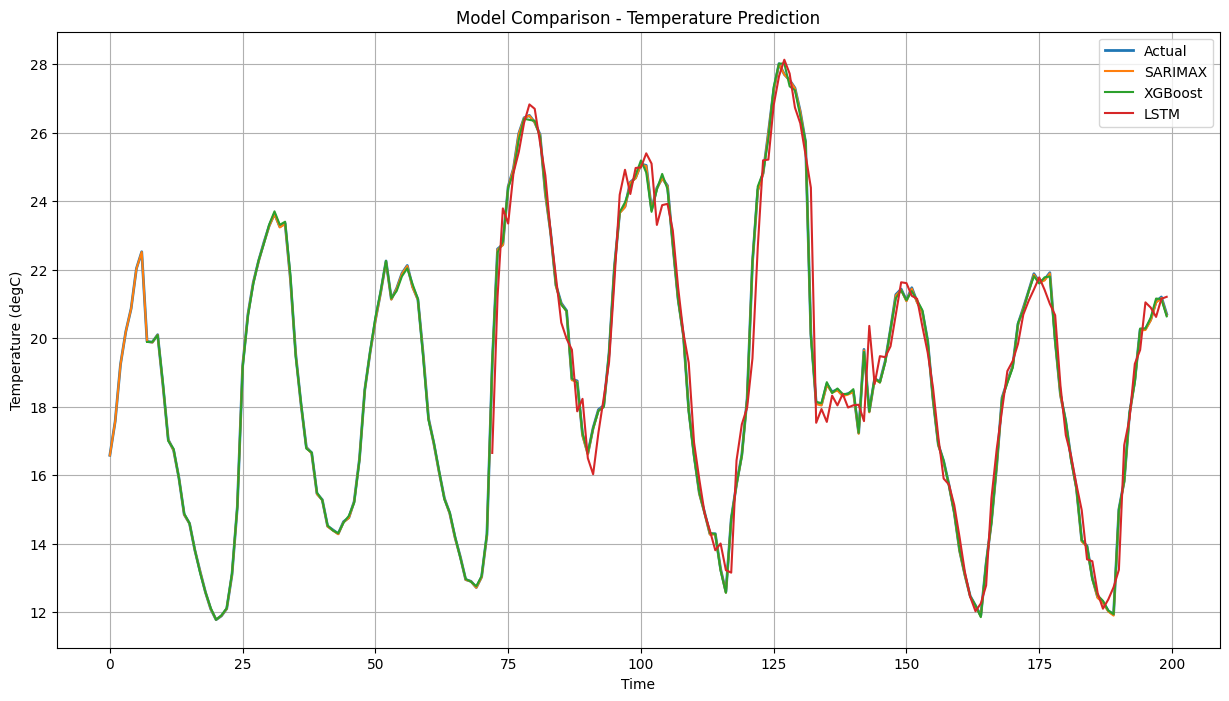

In [31]:
plt.figure(figsize=(15,8))

# Actual
plt.plot(y_test.values[:200],label='Actual',linewidth=2)
# SARIMAX
plt.plot(y_pred_sarimax.values[:200],label='SARIMAX')
# XGBoost
plt.plot(range(7, 7 + 200-7),y_pred_xgb[:200-7],label='XGBoost')
# LSTM
plt.plot(range(72, 72 + 200-72),y_pred_lstm[:200-72],label='LSTM')

plt.title("Model Comparison - Temperature Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature (degC)")
plt.legend()
plt.grid(True)
plt.show()